In [1]:
import geojson
import geopandas as gpd
import rasterio
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import firedrake
import os
from firedrake import Constant, inner, jump, grad, dx, avg, dS, min_value, conditional, pi
import icepack
from matplotlib.colors import LinearSegmentedColormap
import irksome
# import cmcrameri.cm as cmc
# from cmcrameri import show_cmaps
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FormatStrFormatter)

In [2]:
os.getcwd()

'/home/icepack/sync/blue_glacier/code/liam_notebooks'

# Load in Blue Glacier Files:

In [3]:
# Direct from Farinotti data
m1_h  = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_farinotti_model_1.tif'
m2_h  = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_farinotti_model_2.tif'
m3_h  = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_farinotti_model_3.tif'
far_h = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_farinotti_composite.tif'
blue_surf = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_surface_DEM.tif'

# Rasters constructed using Farinotti data
blue_bed_comp =  '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_bedrock_DEM_composite.tif'
#blue_bed_m1
#blue_bed_m2
#blue_bed_m3

# Constructed outline
outline_filename = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue.geojson'

## Make mesh

In [4]:
with open(outline_filename, "r") as outline_file:
    outline = geojson.load(outline_file)

In [5]:
gmsh_mesh = icepack.meshing.collection_to_gmsh(outline)
gmsh_mesh.write("blue.msh", verbose=False)

mesh = firedrake.Mesh("blue.msh") # Initial mesh

In [6]:
from firedrake.mg.mesh import MeshHierarchy

mesh0 = firedrake.Mesh('blue.msh')
hierarchy = MeshHierarchy(mesh0, 3, 1) # I'm unsure if a mesh hierarchy is needed if we're going to do adaptive

mesh = hierarchy[0] 

In [7]:
# This cell is gold for things later
cell_sizes = mesh.cell_sizes.dat.data_ro

print(f'Cells: {mesh.num_cells()}')
print(f'Min: {cell_sizes.min()} m')
print(f'Max: {cell_sizes.max()} m')
print(f'Avg: {cell_sizes.mean()} m')

Cells: 567
Min: 32.21204029831187 m
Max: 457.02138063393437 m
Avg: 183.79866155009674 m


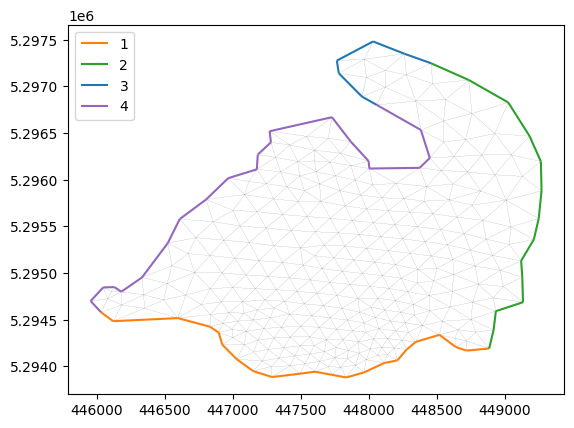

In [8]:
fig, axes = plt.subplots()
kw = {
    "boundary_kw": {"colors": ["tab:orange", "tab:green", "tab:blue", "tab:purple"]},
    "interior_kw": {"linewidth": 0.03}, # Change lw val to smaller number to make boundaries easier to see
}
firedrake.triplot(mesh, axes=axes, **kw)
axes.legend(loc="upper left");

In [9]:
## Function Spaces
dg1 = firedrake.FiniteElement("DG", "triangle", 1)
cg1 = firedrake.FiniteElement("CG", "triangle", 1)

Q = firedrake.FunctionSpace(mesh, dg1) 
V = firedrake.VectorFunctionSpace(mesh, cg1)

# Plot each to see if they all line up

In [10]:
coords = np.array(list(geojson.utils.coords(outline)))
delta = 1e3
extent = {
    "left": coords[:, 0].min() - 1 * delta,
    "right": coords[:, 0].max() + delta,
    "bottom": coords[:, 1].min() - 1 * delta,
    "top": coords[:, 1].max() + delta,
}

In [11]:
# Surface File and Bed file
surf_file_far = rasterio.open(far_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=surf_file_far.transform).round_lengths().round_offsets()
transform = surf_file_far.window_transform(window)
FarinottiSurf_obs = surf_file_far.read(window=window)

#surf_file = rasterio.open(dave_surface)
#window = rasterio.windows.from_bounds(**extent, 
#                                      transform=surf_file.transform).round_lengths().round_offsets()
#transform = surf_file.window_transform(window)
#DaveSurf_obs = surf_file.read(window=window)

# Filtering Fill Vals
#DaveSurf_obs[DaveSurf_obs < 0] = 0

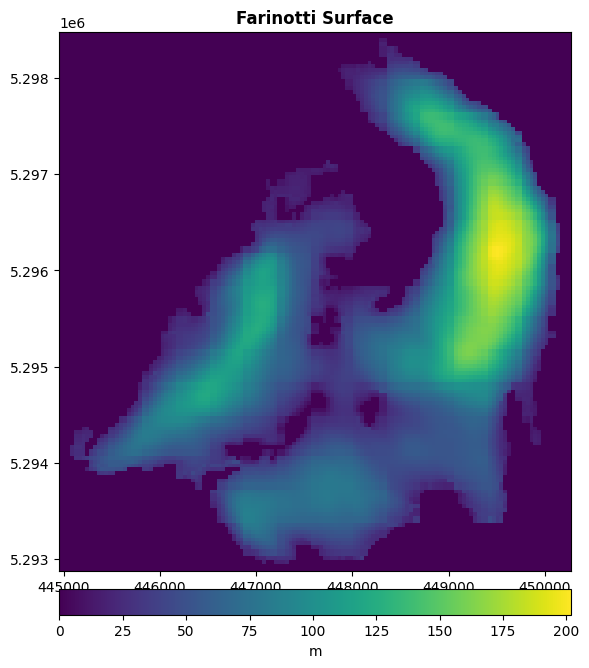

In [12]:
fig, ax = plt.subplots(1, 1, figsize = [6, 7], sharey = True)

colors = ax.imshow(FarinottiSurf_obs[0, :, :],
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      #cmap = cmap2,
                      #vmin = 1500,
                      axes=ax)
fig.colorbar(colors, label="m", location = 'bottom', fraction=0.046, pad=0.03)
ax.set_title('Farinotti Surface', fontweight = 'bold')
ax.set_aspect("equal")

plt.tight_layout()

In [13]:
# Surface File
surf_file = rasterio.open(blue_surf)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=surf_file.transform).round_lengths().round_offsets()
transform = surf_file.window_transform(window)
s_obs = surf_file.read(window=window)

# Filtering Fill Vals
s_obs = s_obs[0, :, :]
s_obs[s_obs < 0] = 0

# Bed File
bed_file = rasterio.open(blue_bed_comp)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=bed_file.transform).round_lengths().round_offsets()
transform = bed_file.window_transform(window)
b_obs = bed_file.read(window=window)

# Filtering Fill Vals
b_obs = b_obs[0, :, :]
b_obs[b_obs < 0] = 0

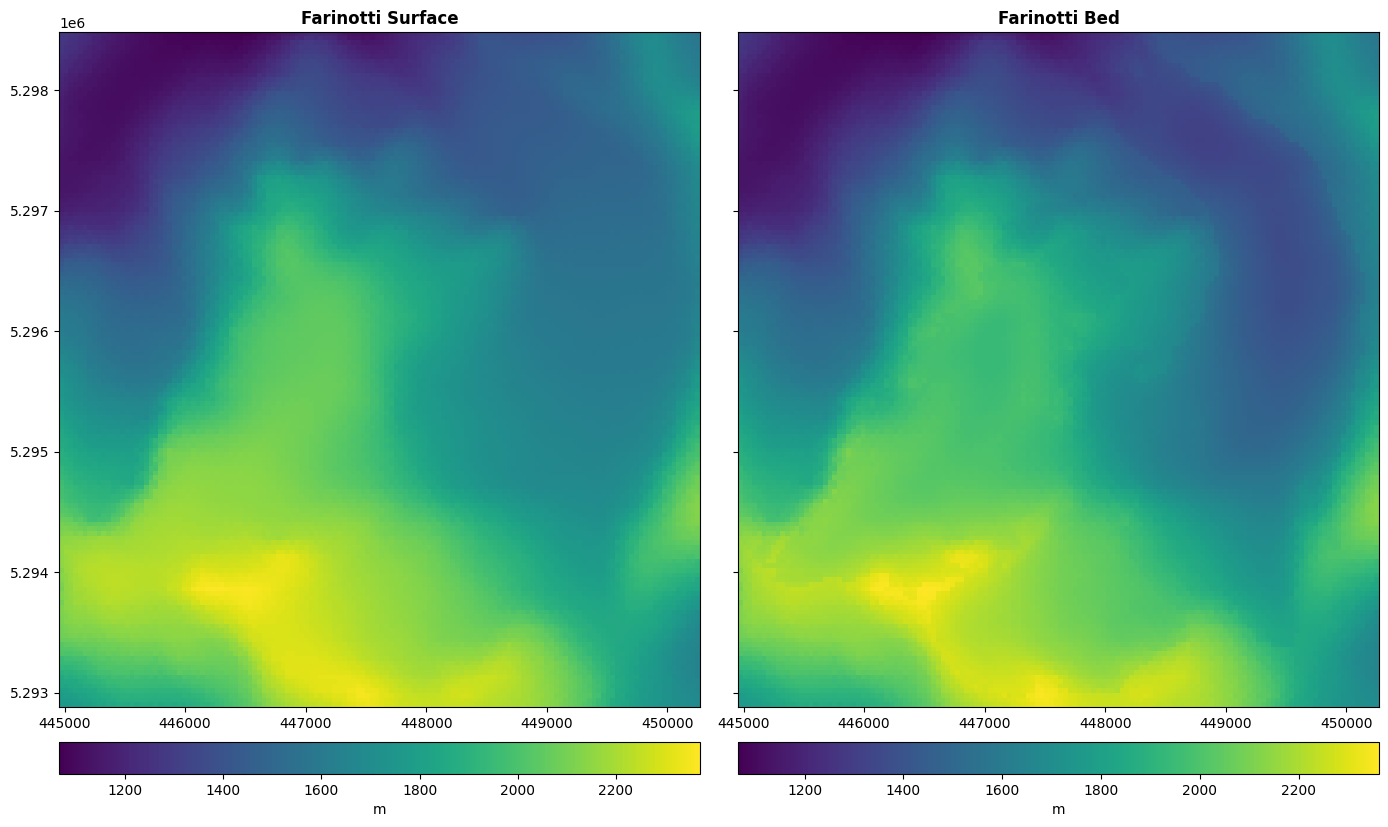

In [14]:
# Surface and Bed File
cmap3 = LinearSegmentedColormap.from_list('', ['white', 'tab:blue', 'tab:orange'])
fig, ax = plt.subplots(1, 2, figsize = [14, 12], sharey = True)

colors = ax[0].imshow(s_obs, 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      #cmap = cmap3,
                      #vmin = 1500,
                      axes=ax[0])
fig.colorbar(colors, label="m", location = 'bottom', fraction=0.046, pad=0.03)
ax[0].set_title('Farinotti Surface', fontweight = 'bold')
ax[0].set_aspect("equal")

colors = ax[1].imshow(b_obs, 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      #cmap = cmap3,
                      #vmin = 1500,                        
                      axes=ax[1])
fig.colorbar(colors, label="m", location = 'bottom', fraction=0.046, pad=0.03)
ax[1].set_title('Farinotti Bed', fontweight = 'bold')
ax[1].set_aspect("equal")

plt.tight_layout()

In [15]:
# Thickness Files (Model est. from Farinotti)
m1_file = rasterio.open(m1_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=m1_file.transform).round_lengths().round_offsets()
transform = m1_file.window_transform(window)
m1_obs = m1_file.read(window=window)

m2_file = rasterio.open(m2_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=m2_file.transform).round_lengths().round_offsets()
transform = m2_file.window_transform(window)
m2_obs = m2_file.read(window=window)

m3_file = rasterio.open(m3_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=m3_file.transform).round_lengths().round_offsets()
transform = m3_file.window_transform(window)
m3_obs = m3_file.read(window=window)

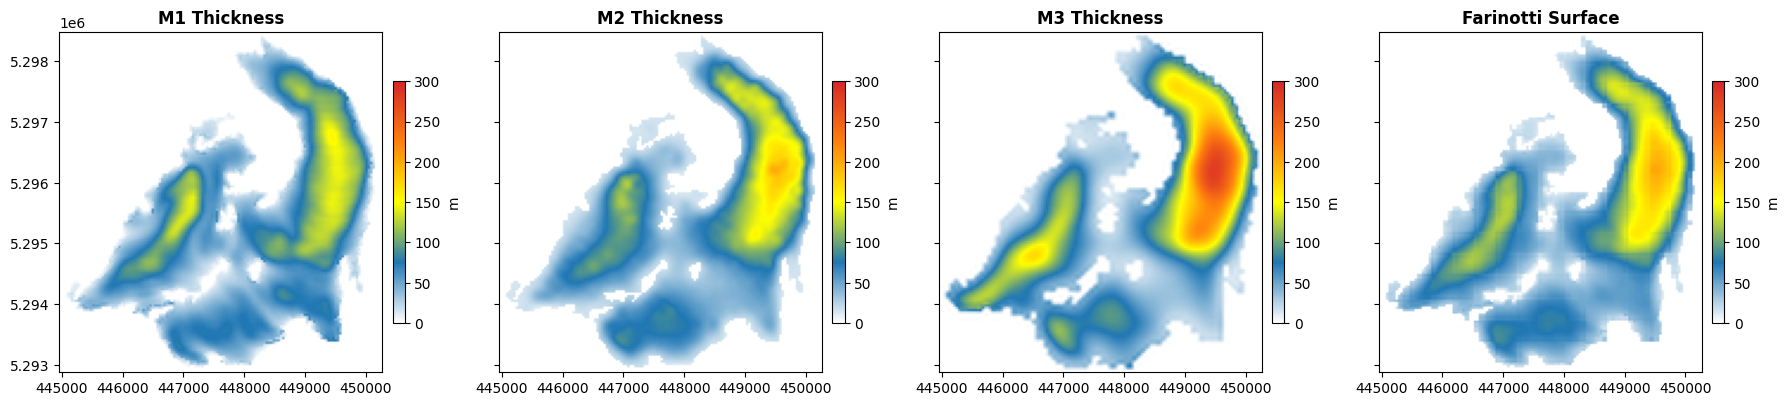

In [16]:
# Thickess Plts
cmap2 = LinearSegmentedColormap.from_list('', ['white', 'tab:blue', 'yellow', 'tab:orange', 'tab:red'])

fig, ax = plt.subplots(1, 4, figsize = [18, 16], sharey = True)

colors = ax[0].imshow(m1_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 300,
                      axes=ax[0])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[0].set_title('M1 Thickness', fontweight = 'bold')
ax[0].set_aspect("equal")

colors = ax[1].imshow(m2_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 300,                        
                      axes=ax[1])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[1].set_title('M2 Thickness', fontweight = 'bold')
ax[1].set_aspect("equal")

colors = ax[2].imshow(m3_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 300,                        
                      axes=ax[2])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[2].set_title('M3 Thickness', fontweight = 'bold')
ax[2].set_aspect("equal")

colors = ax[3].imshow(FarinottiSurf_obs[0, :, :],
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 300,
                      axes=ax[3])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[3].set_title('Farinotti Surface', fontweight = 'bold')
ax[3].set_aspect("equal")

plt.tight_layout()